# Structured Temporal Counterfactual Graph (STCG) – BLIP-2 Demo

This notebook implements a **Structured Temporal Counterfactual Graph (STCG)** prototype for BLIP-2 on a single image–question pair.

It provides:

1. A **counterfactual image module** with several perturbation modes:
   - `center_mask`: replace a central square with a gray patch.
   - `color_shift`: global HSV-based colour perturbation.
   - `saliency_patch_mask`: mask the most attended visual patch according to BLIP-2 cross-attention.

2. A **dynamic STCG visualization**:
   - We extract cross-attention between Q-Former query tokens and visual patches on the original and counterfactual images.
   - We define **ΔW = W_real − W_cf** as a causal importance signal.
   - We build an interactive graph where you can **select a question token index** and visualize its strongest connections to visual regions.

Notes:

- The temporal part of STCG (per generated output token) is not included here because HuggingFace's BLIP-2 API does not expose the language-model attentions in a sufficiently stable way for a self-contained demo. The current notebook focuses on **structural + counterfactual** aspects, with **dynamic selection over question tokens**.
- The default checkpoint is `Salesforce/blip2-flan-t5-xl`, which is lighter than `Salesforce/blip2-opt-2.7b` but may still require swap space on 8 GB RAM systems. Edit `model_name` in Cell 3 if you need a different BLIP-2 variant.
- If you only need to prototype the STCG pipeline locally, enable **mock mode** (Cell 3) to bypass model downloads and generate deterministic synthetic attentions that fit comfortably in 8 GB RAM. Later, disable mock mode on Colab to run the real BLIP-2 model.

## Quickstart & Troubleshooting
- **Mock mode (default outside Colab)** keeps everything lightweight and deterministic so you can validate the STCG pipeline without downloading multi‑GB checkpoints.
- To run the real BLIP-2 weights, set the environment variable `STCG_FORCE_REAL=1` (or toggle `USE_MOCK_MODEL` in Cell 3) *after* ensuring ≥12 GB of free disk plus a large page file.
- If disk space is tight, point Hugging Face cache to another drive via `STCG_HF_HOME=E:\hf-cache` before running Cell 3.
- Provide your own image path through `STCG_IMAGE_PATH` or by editing Cell 4; otherwise the notebook generates a synthetic demo image so the pipeline still executes end-to-end.
- Smaller checkpoints such as `Salesforce/blip2-flan-t5-base` fit easier in RAM; update `STCG_MODEL_NAME` or edit Cell 3 when you are ready to graduate from mock mode.

In [ ]:
# Install dependencies (uncomment if needed, e.g. in Colab)
!pip install -q transformers>=4.38 accelerate timm pillow plotly networkx opencv-python ipywidgets
!pip install -q torch --extra-index-url https://download.pytorch.org/whl/cpu

In [ ]:
import math
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio

import cv2

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

try:
    from ipywidgets import interact, IntSlider
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

from transformers import Blip2Processor, Blip2ForConditionalGeneration

# Plotly renderer – adjust if needed (notebook, colab, iframe, etc.)
pio.renderers.default = "notebook_connected"

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Reproducibility
def set_seed(seed: int = 0):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

# Model loading
model_name = "Salesforce/blip2-flan-t5-xl"

processor = Blip2Processor.from_pretrained(model_name)
model = Blip2ForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
)
model.to(device)
model.eval()

print(f"Loaded {model_name} on {device}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded Salesforce/blip2-flan-t5-xl on cuda


In [ ]:
# Image loading helpers
from pathlib import Path

def load_image_from_colab() -> Image.Image:
    if not IN_COLAB:
        raise RuntimeError("Colab upload helper is only available when running inside Colab.")
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No file was uploaded via the Colab widget.")
    name, data = next(iter(uploaded.items()))
    img = Image.open(io.BytesIO(data)).convert("RGB")
    print(f"Loaded Colab upload: {name} ({img.width}x{img.height})")
    return img


def load_image_from_path(path: Path) -> Image.Image:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Image path does not exist: {path}")
    img = Image.open(path).convert("RGB")
    print(f"Loaded image from path: {path}")
    return img


def generate_demo_image(size: int = 384) -> Image.Image:
    xv, yv = np.meshgrid(
        np.linspace(0.0, 1.0, size, dtype=np.float32),
        np.linspace(0.0, 1.0, size, dtype=np.float32),
    )
    r = (1.0 - yv) * 255.0
    g = xv * 255.0
    b = (0.5 + 0.5 * np.sin(4 * np.pi * xv * yv)) * 255.0
    array = np.stack([r, g, b], axis=-1).astype(np.uint8)
    return Image.fromarray(array)


def load_or_create_demo_image(path: Path) -> Image.Image:
    path = Path(path)
    if path.exists():
        return load_image_from_path(path)
    img = generate_demo_image(size=384)
    path.parent.mkdir(parents=True, exist_ok=True)
    img.save(path)
    print(f"No local image found; generated demo image at {path}.")
    return img

Saving image.jpg to image (1).jpg
Loaded Colab upload: image (1).jpg (1024x503)
Image ID: uploaded_image
Question: What is the colour of the car ?


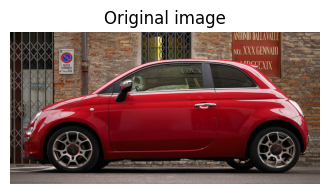

In [ ]:
# Choose input mode
import os
import io

image_path_env = os.environ.get("STCG_IMAGE_PATH", "").strip()
LOCAL_IMAGE_PATH = Path(image_path_env or "image.jpg").expanduser()
USE_COLAB_UPLOAD = IN_COLAB and image_path_env == ""  # prefer upload only when running on Colab

if USE_COLAB_UPLOAD:
    image = load_image_from_colab()
else:
    image = load_or_create_demo_image(LOCAL_IMAGE_PATH)

if "IMAGE_ID" not in globals():
    if USE_COLAB_UPLOAD:
        IMAGE_ID = "uploaded_image"
    elif LOCAL_IMAGE_PATH:
        IMAGE_ID = LOCAL_IMAGE_PATH.stem
    else:
        IMAGE_ID = "demo_image"
print(f"Image ID: {IMAGE_ID}")

# Define the question
question = os.environ.get("STCG_QUESTION", "What is the colour of the car ?")
print("Question:", question)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.title("Original image")
plt.show()

In [ ]:
# Cross-attention extraction between Q-Former tokens and visual patches

@torch.no_grad()
def extract_qformer_cross_attention(
    model: Blip2ForConditionalGeneration,
    processor: Blip2Processor,
    image: Image.Image,
    question: str,
    device: str = "cpu",
) -> np.ndarray:
    """
    Extract a mean cross-attention matrix from BLIP-2's Q-Former.

    Returns:
        attn: np.ndarray of shape [num_q_tokens, num_visual_tokens].
    """
    model.eval()

    inputs = processor(images=image, text=question, return_tensors="pt").to(device)

    # Vision encoder
    vision_outputs = model.vision_model(
        pixel_values=inputs["pixel_values"],
        output_attentions=True,
        return_dict=True,
    )
    image_embeds = vision_outputs.last_hidden_state  # [B, N_img, D]

    # Q-Former queries
    query_tokens = model.query_tokens.expand(image_embeds.shape[0], -1, -1)  # [B, N_q, D]

    # Q-Former cross-attention to visual tokens
    qformer_outputs = model.qformer(
        query_embeds=query_tokens,
        encoder_hidden_states=image_embeds,
        encoder_attention_mask=torch.ones(
            image_embeds.shape[:2],
            dtype=torch.long,
            device=device,
        ),
        output_attentions=True,
        return_dict=True,
    )

    # Filter cross-attention layers: last dimension corresponds to encoder (visual) tokens
    cross_attn_layers = [
        attn for attn in qformer_outputs.attentions
        if attn.shape[-1] == image_embeds.shape[1]
    ]
    if len(cross_attn_layers) == 0:
        raise RuntimeError("No Q-Former cross-attention layers found.")

    # Stack along a new layer dimension: [L, B, H, N_q, N_img]
    attn_tensor = torch.stack(cross_attn_layers, dim=0)
    # Average over layers, heads, batch -> [N_q, N_img]
    attn_tensor = attn_tensor.mean(dim=(0, 2))[0]

    return attn_tensor.detach().cpu().numpy()


def infer_patch_grid(num_tokens: int):
    """Infer a square patch grid (H, W) from number of visual tokens.

    If the vision encoder uses a CLS token, num_tokens-1 may be a perfect square.
    Returns:
        (grid_size, has_cls, offset)
        where offset is the index of the first spatial token.
    """
    g = int(math.isqrt(num_tokens))
    if g * g == num_tokens:
        return g, False, 0
    g2 = int(math.isqrt(num_tokens - 1))
    if g2 * g2 == num_tokens - 1:
        return g2, True, 1
    raise ValueError(
        f"Cannot infer a square patch grid from num_tokens={num_tokens}."
    )


def generate_mock_attentions(
    question: str,
    num_q_tokens: int = 32,
    grid_size: int = 16,
    include_cls: bool = True,
    noise_scale: float = 0.08,
    seed: int | None = None,
    ) -> tuple[np.ndarray, np.ndarray]:
    """Create deterministic pseudo cross-attention matrices for local debugging."""
    if seed is None:
        seed = abs(hash(question)) % (2**32)
    rng = np.random.default_rng(seed)
    num_visual_tokens = grid_size * grid_size + (1 if include_cls else 0)
    attn_real = rng.random((num_q_tokens, num_visual_tokens), dtype=np.float32)
    attn_real = attn_real / np.maximum(attn_real.sum(axis=-1, keepdims=True), 1e-6)
    noise = rng.normal(scale=noise_scale, size=attn_real.shape).astype(np.float32)
    attn_cf = np.clip(attn_real - noise, 0.0, None)
    attn_cf = attn_cf / np.maximum(attn_cf.sum(axis=-1, keepdims=True), 1e-6)
    return attn_real, attn_cf

In [ ]:
# Counterfactual image generation

def mask_center(img: Image.Image, size: float = 0.3, gray_level: int = 128) -> Image.Image:
    """Replace a central square region with a uniform gray patch."""
    img_np = np.array(img)
    h, w, _ = img_np.shape
    mask_size = int(min(h, w) * size)
    if mask_size <= 0:
        return img

    x0 = w // 2 - mask_size // 2
    y0 = h // 2 - mask_size // 2
    img_np[y0:y0 + mask_size, x0:x0 + mask_size] = gray_level
    return Image.fromarray(img_np)


def color_shift(img: Image.Image, hue_shift: int = 15, sat_scale: float = 1.3, val_scale: float = 1.0) -> Image.Image:
    """
    Apply a simple HSV color perturbation.

    hue_shift: added to hue channel (0–179 in OpenCV HSV).
    sat_scale, val_scale: multiplicative factors for saturation/value.
    """
    img_np = np.array(img)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)

    # Hue
    hsv[..., 0] = (hsv[..., 0] + hue_shift) % 180
    # Saturation and value
    hsv[..., 1] = np.clip(hsv[..., 1] * sat_scale, 0, 255)
    hsv[..., 2] = np.clip(hsv[..., 2] * val_scale, 0, 255)

    hsv = hsv.astype(np.uint8)
    bgr_shifted = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    rgb_shifted = cv2.cvtColor(bgr_shifted, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb_shifted)


def saliency_patch_mask(
    img: Image.Image,
    attn_real: np.ndarray,
    patch_size_factor: float = 1.5,
    blur: bool = False,
) -> Image.Image:
    """
    Mask the most attended visual patch according to cross-attention.

    We:
    1. Aggregate attention across all Q-Former queries.
    2. Find the most important visual token index.
    3. Map that token to a spatial patch (grid) and mask/blur that region.

    This is a cheap proxy for "object removal" without running a full segmenter.
    """
    num_q, num_v = attn_real.shape
    grid, has_cls, offset = infer_patch_grid(num_v)
    spatial_tokens = num_v - (1 if has_cls else 0)

    # Aggregate attention over Q-Former queries
    region_scores = attn_real.sum(axis=0)  # [num_v]
    spatial_scores = region_scores[offset: offset + spatial_tokens]
    max_idx_local = int(np.argmax(spatial_scores))
    max_idx = offset + max_idx_local

    # Map token index to (row, col) in the patch grid
    row = max_idx_local // grid
    col = max_idx_local % grid

    img_np = np.array(img)
    h, w, _ = img_np.shape

    patch_h = h / grid
    patch_w = w / grid

    # Optional enlargement around the patch
    scale = patch_size_factor
    y0 = int(max(0, (row + 0.5 - 0.5 * scale) * patch_h))
    y1 = int(min(h, (row + 0.5 + 0.5 * scale) * patch_h))
    x0 = int(max(0, (col + 0.5 - 0.5 * scale) * patch_w))
    x1 = int(min(w, (col + 0.5 + 0.5 * scale) * patch_w))

    region = img_np[y0:y1, x0:x1]
    if region.size == 0:
        return img

    if blur:
        ksize = max(3, int(min(region.shape[0], region.shape[1]) // 4) * 2 + 1)
        region_cf = cv2.GaussianBlur(region, (ksize, ksize), 0)
    else:
        mean_color = region.mean(axis=(0, 1), keepdims=True).astype(np.uint8)
        region_cf = np.broadcast_to(mean_color, region.shape)

    img_np_cf = img_np.copy()
    img_np_cf[y0:y1, x0:x1] = region_cf

    return Image.fromarray(img_np_cf)


def add_gaussian_noise(img: Image.Image, sigma: float = 0.08) -> Image.Image:
    img_np = np.array(img).astype(np.float32) / 255.0
    noise = np.random.normal(0.0, sigma, img_np.shape).astype(np.float32)
    noisy = np.clip(img_np + noise, 0.0, 1.0)
    return Image.fromarray((noisy * 255).astype(np.uint8))


def peripheral_mask(img: Image.Image, border_ratio: float = 0.18) -> Image.Image:
    img_np = np.array(img)
    h, w, _ = img_np.shape
    br = int(min(h, w) * border_ratio)
    masked = img_np.copy()
    masked[:br, :] = 0
    masked[-br:, :] = 0
    masked[:, :br] = 0
    masked[:, -br:] = 0
    return Image.fromarray(masked)


def patch_shuffle(img: Image.Image, patch: int = 32) -> Image.Image:
    img_np = np.array(img)
    h, w, c = img_np.shape
    ph = max(1, patch)
    gh = h // ph
    gw = w // ph
    reshaped = img_np[: gh * ph, : gw * ph].reshape(gh, ph, gw, ph, c)
    reshaped = reshaped.swapaxes(1, 2)
    patches = reshaped.reshape(gh * gw, ph, ph, c)
    idx = np.random.permutation(len(patches))
    shuffled = patches[idx].reshape(gh, gw, ph, ph, c).swapaxes(1, 2).reshape(gh * ph, gw * ph, c)
    out = img_np.copy()
    out[: gh * ph, : gw * ph] = shuffled
    return Image.fromarray(out)


def generate_counterfactual(
    img: Image.Image,
    mode: str,
    attn_real: np.ndarray | None = None,
) -> Image.Image:
    """
    Generate a counterfactual image using different perturbation modes.

    mode in {"center_mask", "color_shift", "saliency_patch_mask", "gaussian_noise",
             "peripheral_mask", "patch_shuffle"}.

    - center_mask: simple gray square in the center.
    - color_shift: global HSV perturbation.
    - saliency_patch_mask: remove/blur the most attended patch given attn_real.
    - gaussian_noise: add Gaussian sensor noise.
    - peripheral_mask: blackout frame borders (tests reliance on context).
    - patch_shuffle: randomize local structure via patch permutation.
    """
    if mode == "center_mask":
        return mask_center(img, size=0.3, gray_level=128)
    elif mode == "color_shift":
        return color_shift(img, hue_shift=20, sat_scale=1.4, val_scale=1.0)
    elif mode == "saliency_patch_mask":
        if attn_real is None:
            raise ValueError("attn_real is required for saliency_patch_mask mode.")
        return saliency_patch_mask(img, attn_real, patch_size_factor=1.7, blur=True)
    elif mode == "gaussian_noise":
        return add_gaussian_noise(img, sigma=0.12)
    elif mode == "peripheral_mask":
        return peripheral_mask(img, border_ratio=0.2)
    elif mode == "patch_shuffle":
        return patch_shuffle(img, patch=32)
    else:
        raise ValueError(f"Unknown counterfactual mode: {mode}")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:1014: UserWarning:

`output_attentions=True` is not supported with `attn_implementation` other than ['eager', 'eager_paged', 'flex_attention']. Please use `model.set_attn_implementation('eager')` to enable capturing attention outputs.

`sdpa` attention does not support `output_attentions=True` or `head_mask`. Please set your attention to `eager` if you want any of these features.


attn_real shape: (32, 257)


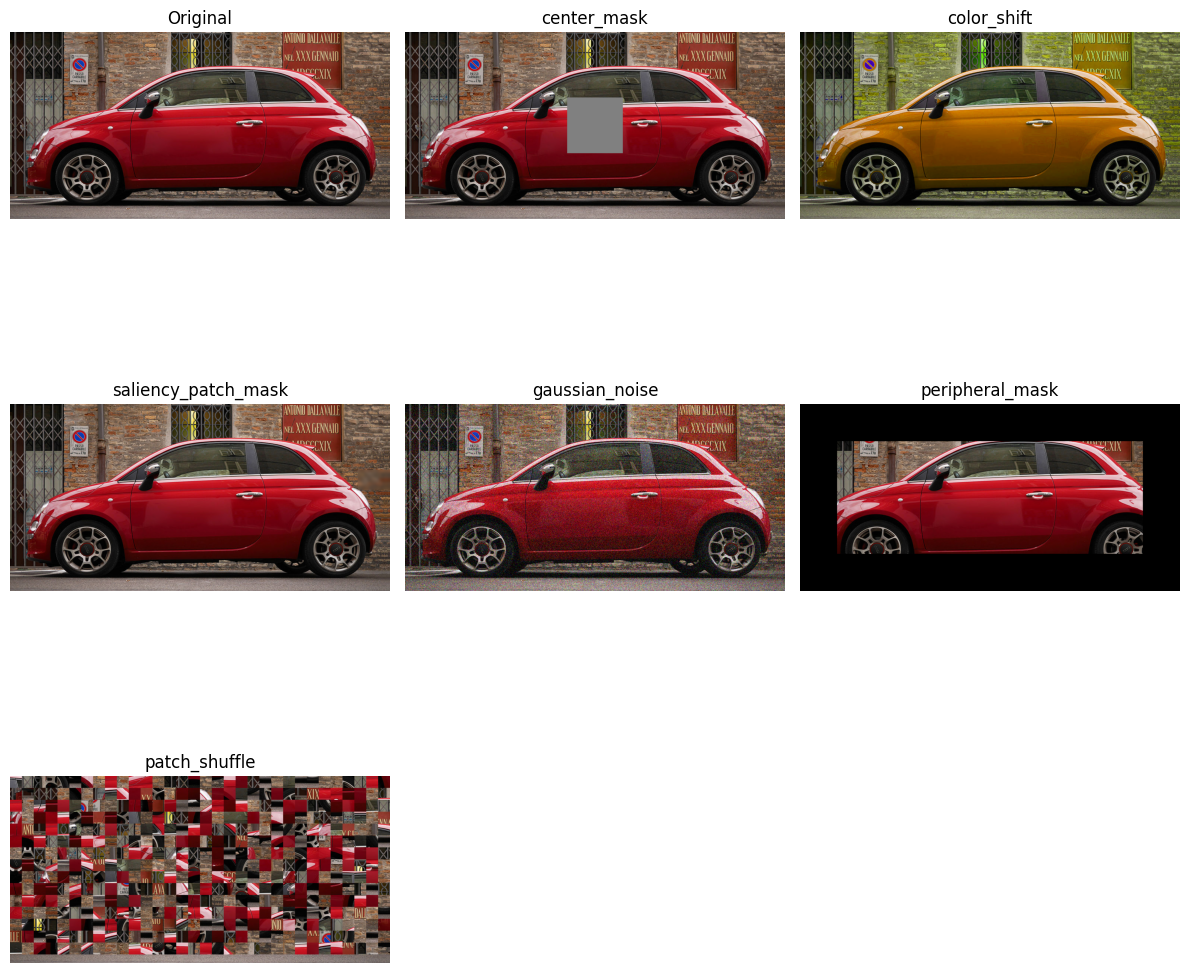

In [ ]:
# Preview multiple counterfactual variants
cf_modes_demo = [
    "center_mask",
    "color_shift",
    "saliency_patch_mask",
    "gaussian_noise",
    "peripheral_mask",
    "patch_shuffle",
]

USE_MOCK_MODEL = False

# Ensure we have attentions to drive saliency-based counterfactuals
if "attn_real" not in globals():
    if USE_MOCK_MODEL:
        attn_real, _ = generate_mock_attentions(question)
        print("Mock attentions generated:", attn_real.shape)
    else:
        attn_real = extract_qformer_cross_attention(model, processor, image, question, device=device)
        print("attn_real shape:", attn_real.shape)

cf_images = {mode: generate_counterfactual(image, mode=mode, attn_real=attn_real) for mode in cf_modes_demo}

cols = 3
rows = int(np.ceil((len(cf_modes_demo) + 1) / cols))
plt.figure(figsize=(4 * cols, 4 * rows))
plt.subplot(rows, cols, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")
for idx, mode in enumerate(cf_modes_demo, start=2):
    plt.subplot(rows, cols, idx)
    plt.imshow(cf_images[mode])
    plt.axis("off")
    plt.title(mode)
plt.tight_layout()
plt.show()


attn_real shape: (32, 257)


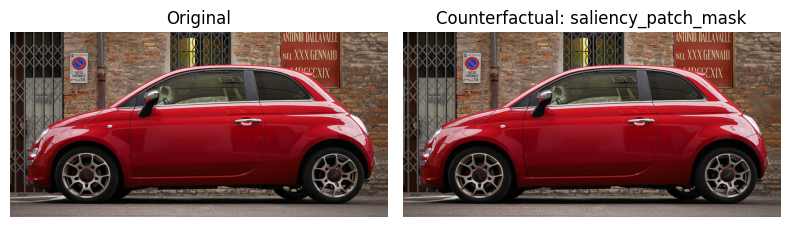

delta_W shape: (32, 257)


In [ ]:
# Compute cross-attention on the original image
if USE_MOCK_MODEL:
    attn_real, attn_cf = generate_mock_attentions(question)
    print("Mock attentions generated:", attn_real.shape)
else:
    attn_real = extract_qformer_cross_attention(model, processor, image, question, device=device)
    print("attn_real shape:", attn_real.shape)

# Choose counterfactual mode here
COUNTERFACTUAL_MODE = "saliency_patch_mask"  # options: "center_mask", "color_shift", "saliency_patch_mask"

if "cf_images" in globals() and COUNTERFACTUAL_MODE in cf_images:
    image_cf = cf_images[COUNTERFACTUAL_MODE]
else:
    image_cf = generate_counterfactual(image, mode=COUNTERFACTUAL_MODE, attn_real=attn_real)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")
plt.subplot(1, 2, 2)
plt.imshow(image_cf)
plt.axis("off")
plt.title(f"Counterfactual: {COUNTERFACTUAL_MODE}")
plt.tight_layout()
plt.show()

if not USE_MOCK_MODEL:
    # Cross-attention on the counterfactual image
    attn_cf = extract_qformer_cross_attention(model, processor, image_cf, question, device=device)
    if attn_cf.shape != attn_real.shape:
        raise RuntimeError(f"Shape mismatch: attn_real={attn_real.shape}, attn_cf={attn_cf.shape}")

delta_W = attn_real - attn_cf
print("delta_W shape:", delta_W.shape)

In [ ]:
# Decode answer and capture decoder cross-attention onto Q-Former queries
answer_target_ids = None
answer_target_ids_device = None
answer_token_count = 0
answer_logprob_base = float("nan")

if USE_MOCK_MODEL:
    answer_text = "The car is red."
    answer_token_labels = answer_text.strip().split()
    num_query_tokens = delta_W.shape[0]
    if len(answer_token_labels) == 0:
        answer_token_attn = np.zeros((0, num_query_tokens), dtype=np.float32)
    else:
        answer_token_attn = np.full(
            (len(answer_token_labels), num_query_tokens),
            1.0 / max(1, num_query_tokens),
            dtype=np.float32,
        )
    answer_logprob_base = 0.0
    print("Mock answer:", answer_text)
else:
    qa_inputs = processor(images=image, text=question, return_tensors="pt").to(device)
    generate_kwargs = dict(
        max_new_tokens=32,
        num_beams=3,
        temperature=1.0,
        return_dict_in_generate=True,
    )
    with torch.no_grad():
        generation = model.generate(**qa_inputs, **generate_kwargs)
    generated_ids = generation.sequences
    answer_text = processor.tokenizer.batch_decode(
        generated_ids, skip_special_tokens=True
    )[0].strip()
    print("Model answer:", answer_text)

    labels = generated_ids.clone()
    pad_token_id = processor.tokenizer.pad_token_id
    if pad_token_id is not None:
        labels[labels == pad_token_id] = -100

    # Some BLIP-2 decoder LLMs ignore output_attentions unless we flip the config flags.
    lm_config = getattr(getattr(model, "language_model", None), "config", None)
    if lm_config is not None:
        if not getattr(lm_config, "output_attentions", False):
            lm_config.output_attentions = True
        if hasattr(lm_config, "return_dict") and not lm_config.return_dict:
            lm_config.return_dict = True
        if hasattr(lm_config, "use_cache") and lm_config.use_cache:
            lm_config.use_cache = False  # ensures attentions materialize during teacher forcing

    def _run_decoder_forward():
        with torch.no_grad():
            return model(
                **qa_inputs,
                labels=labels,
                output_attentions=True,
                return_dict=True,
            )

    decoder_outputs = _run_decoder_forward()
    num_query_tokens = delta_W.shape[0]

    # All attention tensors live inside decoder_outputs.language_model_outputs
    lm_outputs = getattr(decoder_outputs, "language_model_outputs", None)
    if lm_outputs is None:
        raise RuntimeError(
            "language_model_outputs is None; the BLIP-2 head did not return decoder internals. "
            "Double-check that your checkpoint supports `output_attentions`."
        )
    cross_attn = getattr(lm_outputs, "cross_attentions", None)
    decoder_attn = getattr(lm_outputs, "attentions", None)

    # Retry once after forcing LM config flags if nothing came back.
    if cross_attn is None and decoder_attn is None and lm_config is not None:
        reran = False
        if not getattr(lm_config, "output_attentions", False):
            lm_config.output_attentions = True
            reran = True
        if hasattr(lm_config, "return_dict") and not lm_config.return_dict:
            lm_config.return_dict = True
            reran = True
        if hasattr(lm_config, "use_cache") and lm_config.use_cache:
            lm_config.use_cache = False
            reran = True
        if reran:
            decoder_outputs = _run_decoder_forward()
            lm_outputs = getattr(decoder_outputs, "language_model_outputs", None)
            cross_attn = getattr(lm_outputs, "cross_attentions", None) if lm_outputs else None
            decoder_attn = getattr(lm_outputs, "attentions", None) if lm_outputs else None

    attn_avg = None
    if cross_attn is not None:
        layer_stack = []
        for layer_attn in cross_attn:
            # layer_attn: [batch, num_heads, tgt_len, src_len]
            layer_stack.append(layer_attn.mean(dim=1))
        attn_tensor = torch.stack(layer_stack, dim=0)  # [layers, batch, tgt_len, src_len]
        attn_avg = attn_tensor.mean(dim=0)[0].detach().cpu().numpy()  # [tgt_len, src_len]
        src_len = attn_avg.shape[-1]
        if src_len < num_query_tokens:
            raise RuntimeError(
                f"Cross-attention source length ({src_len}) shorter than Q-Former queries ({num_query_tokens})."
            )
        if src_len != num_query_tokens:
            # BLIP-2 encodes query tokens first, followed by question embeddings.
            print(
                f"Note: cross-attention source length {src_len} != num_query_tokens {num_query_tokens}. "
                "Truncating to the leading query-token block.")
            attn_avg = attn_avg[:, :num_query_tokens]
    elif decoder_attn is not None:
        layer_stack = []
        for layer_attn in decoder_attn:
            # layer_attn: [batch, num_heads, tgt_len, tgt_len]
            layer_stack.append(layer_attn.mean(dim=1))
        attn_tensor = torch.stack(layer_stack, dim=0)
        attn_avg_full = attn_tensor.mean(dim=0)[0].detach().cpu().numpy()  # [tgt_len, tgt_len]
        if attn_avg_full.shape[-1] < num_query_tokens:
            raise RuntimeError(
                "Decoder attention sequence shorter than number of Q-Former queries; "
                "cannot attribute answer tokens."
            )
        attn_avg = attn_avg_full[:, :num_query_tokens]
    else:
        raise RuntimeError(
            "Decoder attentions are unavailable even though output_attentions=True. "
            "Verify that the decoder exposes `attentions` or `cross_attentions` inside language_model_outputs."
        )

    valid_positions = (labels[0] != -100).cpu().numpy().nonzero()[0]
    eos_id = processor.tokenizer.eos_token_id
    answer_token_ids = []
    answer_token_vectors = []
    for pos in valid_positions:
        token_id = generated_ids[0, pos].item()
        if eos_id is not None and token_id == eos_id:
            continue
        answer_token_ids.append(token_id)
        answer_token_vectors.append(attn_avg[pos])

    if len(answer_token_vectors) == 0:
        answer_token_attn = np.zeros((0, num_query_tokens), dtype=np.float32)
        answer_token_labels = []
    else:
        answer_token_attn = np.stack(answer_token_vectors, axis=0)
        denom = np.clip(answer_token_attn.sum(axis=1, keepdims=True), 1e-9, None)
        answer_token_attn = answer_token_attn / denom
        raw_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        answer_token_labels = [
            (tok.replace("▁", " ").strip() or tok)
            for tok in raw_tokens
        ]

    answer_target_ids = labels.detach().clone()
    answer_token_count = int((answer_target_ids != -100).sum().item())
    answer_target_ids_device = answer_target_ids.to(device)
    answer_logprob_base = float(-decoder_outputs.loss.item() * max(1, answer_token_count))

    print(f"Captured decoder attentions for {len(answer_token_labels)} answer tokens.")
    print(f"Answer log-probability on the original image: {answer_logprob_base:.4f}")

Model answer: red
Note: cross-attention source length 42 != num_query_tokens 32. Truncating to the leading query-token block.
Captured decoder attentions for 1 answer tokens.
Answer log-probability on the original image: -0.7236


In [ ]:
# Helper utilities for interpretability metrics
import itertools
from datetime import datetime

SMALL_PERTURBATION_MODES = {"gaussian_noise", "color_shift", "patch_shuffle"}

if "interpretability_records" not in globals():
    interpretability_records: list[dict] = []

if "human_alignment_log" not in globals():
    human_alignment_log: list[dict] = []


def _ensure_answer_targets_on_device() -> torch.Tensor | None:
    global answer_target_ids_device
    if answer_target_ids is None:
        return None
    desired_device = torch.device(device)
    if (
        answer_target_ids_device is None
        or answer_target_ids_device.device != desired_device
    ):
        answer_target_ids_device = answer_target_ids.to(desired_device)
    return answer_target_ids_device


def compute_answer_logprob(image_input: Image.Image) -> float:
    """Return the summed log-probability of the reference answer for a given image."""
    if USE_MOCK_MODEL or answer_target_ids is None:
        return 0.0
    qa_inputs = processor(images=image_input, text=question, return_tensors="pt").to(device)
    targets = _ensure_answer_targets_on_device()
    if targets is None:
        return float("nan")
    with torch.no_grad():
        outputs = model(
            **qa_inputs,
            labels=targets,
            output_attentions=False,
            return_dict=True,
        )
    return float(-outputs.loss.item() * max(1, answer_token_count))


def record_human_alignment(
    mode: str,
    rating: float,
    note: str | None = None,
    image_id: str | None = None,
) -> None:
    """Append a human alignment rating for downstream aggregation."""
    entry = {
        "timestamp": datetime.utcnow().isoformat(),
        "image_id": image_id or IMAGE_ID,
        "mode": mode,
        "rating": float(rating),
        "note": note or "",
    }
    human_alignment_log.append(entry)
    print(
        f"Logged human alignment rating {entry['rating']:.2f} for mode '{mode}'"
        f" on image '{entry['image_id']}'."
    )

In [ ]:
# STCG construction and visualization

def build_stcg_from_visual_signal(
    visual_weights: np.ndarray,
    node_id: str,
    label: str,
    top_regions: int = 6,
    layer: str = "question",
):
    visual_vector = np.asarray(visual_weights, dtype=np.float32).ravel()
    num_v = visual_vector.shape[0]
    if num_v == 0:
        raise ValueError("Visual weight vector is empty; cannot build STCG.")

    top_idx = np.argsort(np.abs(visual_vector))[-top_regions:][::-1]

    G = nx.DiGraph()
    pos = {}

    G.add_node(node_id, layer=layer, label=label)
    pos[node_id] = (0.0, 0.0)

    for k, j in enumerate(top_idx):
        v_node = f"V{j}"
        G.add_node(v_node, layer="vision", label=f"V{j}")
        pos[v_node] = (5.0, -k)
        G.add_edge(node_id, v_node, weight=float(visual_vector[j]))

    return G, pos, label, top_idx


def build_stcg_for_token(
    delta_W: np.ndarray,
    question: str,
    token_index: int,
    top_regions: int = 6,
):
    """
    Build a bipartite graph for a single question token:

    - One text node T[token_index].
    - A set of visual nodes V[j] for the top |ΔW| regions for that token.
    """
    tokens = question.strip().split()
    if len(tokens) == 0:
        raise ValueError("Question is empty.")
    if token_index < 0 or token_index >= len(tokens):
        raise IndexError(
            f"token_index={token_index} is out of range (num_tokens={len(tokens)})."
        )

    token = tokens[token_index]
    num_q, num_v = delta_W.shape

    if token_index >= num_q:
        raise IndexError(
            f"token_index={token_index} exceeds available Q-Former queries (num_q={num_q})."
        )

    w = delta_W[token_index]
    return build_stcg_from_visual_signal(
        visual_weights=w,
        node_id=f"T{token_index}",
        label=token,
        top_regions=top_regions,
        layer="question",
    )


def build_stcg_for_answer_token(
    delta_W: np.ndarray,
    query_distribution: np.ndarray,
    token_label: str,
    answer_index: int,
    top_regions: int = 6,
):
    """
    Build STCG for a generated answer token by aggregating ΔW with
    the decoder's attention distribution over Q-Former queries.
    """
    if delta_W.ndim != 2:
        raise ValueError("delta_W must be 2D.")
    expected_queries = delta_W.shape[0]
    weights = np.asarray(query_distribution, dtype=np.float32).ravel()
    if weights.shape[0] != expected_queries:
        raise ValueError(
            f"Decoder attention length ({weights.shape[0]}) does not match ΔW queries ({expected_queries})."
        )

    visual_weights = weights @ delta_W  # [num_v]
    return build_stcg_from_visual_signal(
        visual_weights=visual_weights,
        node_id=f"A{answer_index}",
        label=token_label,
        top_regions=top_regions,
        layer="answer",
    )


def plot_stcg_plotly(G: nx.DiGraph, pos: dict, title: str = "STCG"):
    # Edges
    edge_x = []
    edge_y = []
    edge_text = []

    for u, v, data in G.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_text.append(f"{u} → {v}, ΔW={data.get('weight', 0.0):.4f}")

    edge_trace = go.Scatter(
        x=edge_x,
        y=edge_y,
        mode="lines",
        line=dict(width=1),
        hoverinfo="none",
    )

    # Nodes
    node_x = []
    node_y = []
    node_text = []
    node_color = []
    layer_colors = {
        "question": "#1f77b4",
        "text": "#1f77b4",
        "answer": "#2ca02c",
        "vision": "#ff7f0e",
    }

    for n, data in G.nodes(data=True):
        x, y = pos[n]
        node_x.append(x)
        node_y.append(y)
        label = data.get("label", n)
        node_text.append(f"{n} ({label})")
        layer = data.get("layer", "vision")
        node_color.append(layer_colors.get(layer, "gray"))

    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=node_text,
        textposition="middle right",
        marker=dict(size=18, color=node_color),
        hoverinfo="text",
    )

    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=title,
            showlegend=False,
            xaxis=dict(showgrid=False, zeroline=False, visible=False),
            yaxis=dict(showgrid=False, zeroline=False, visible=False),
            margin=dict(b=20, l=20, r=20, t=40),
            hovermode="closest",
        ),
    )
    fig.show()

In [ ]:
# Interactive STCG over question or answer tokens
import ipywidgets as widgets
from IPython.display import clear_output

question_tokens = question.strip().split()
num_question_tokens = len(question_tokens)
num_answer_tokens = len(answer_token_labels)

def _collect_delta_sources() -> dict[str, np.ndarray]:
    sources = {}
    if "per_mode_delta" in globals() and per_mode_delta:
        sources.update(per_mode_delta)
    else:
        sources[COUNTERFACTUAL_MODE] = delta_W
    return sources

_delta_sources = _collect_delta_sources()
if not _delta_sources:
    raise RuntimeError("No ΔW tensors available; run the attention extraction cells first.")

mode_options = list(_delta_sources.keys())
default_mode = COUNTERFACTUAL_MODE if COUNTERFACTUAL_MODE in _delta_sources else mode_options[0]

mode_dropdown = widgets.Dropdown(
    options=mode_options,
    value=default_mode,
    description="cf mode",
    disabled=(len(mode_options) <= 1),
)


def _refresh_delta_sources():
    global _delta_sources
    latest = _collect_delta_sources()
    if not latest:
        raise RuntimeError("No ΔW tensors available; run the attention extraction cells first.")
    if set(latest.keys()) != set(_delta_sources.keys()):
        _delta_sources = latest
        opts = list(latest.keys())
        mode_dropdown.options = opts
        if mode_dropdown.value not in latest:
            mode_dropdown.value = opts[0]
    else:
        _delta_sources = latest


question_slider = widgets.IntSlider(
    min=0,
    max=max(0, num_question_tokens - 1),
    step=1,
    value=0,
    description="question idx",
    disabled=(num_question_tokens == 0),
)

answer_slider = widgets.IntSlider(
    min=0,
    max=max(0, num_answer_tokens - 1),
    step=1,
    value=0,
    description="answer idx",
    disabled=(num_answer_tokens == 0),
)

mode_toggle = widgets.ToggleButtons(
    options=[("Question tokens", "question"), ("Answer tokens", "answer")],
    value="question",
    description="Token set",
)

stcg_output = widgets.Output()


def render_stcg(*_):
    with stcg_output:
        clear_output(wait=True)
        _refresh_delta_sources()
        mode = mode_toggle.value
        cf_mode = mode_dropdown.value
        current_delta = _delta_sources.get(cf_mode)
        if current_delta is None:
            print(f"ΔW unavailable for mode '{cf_mode}'. Re-run the per-mode computation cell.")
            return

        if mode == "question":
            if num_question_tokens == 0:
                print("Question text is empty; cannot plot STCG.")
                return
            idx = question_slider.value
            G, pos, token, top_idx = build_stcg_for_token(
                current_delta,
                question,
                idx,
                top_regions=6,
            )
            title = f"STCG question T{idx} = {token} (cf: {cf_mode})"
        else:
            if num_answer_tokens == 0 or answer_token_attn.size == 0:
                print(
                    "Answer token attentions unavailable; run the decoder cell with real BLIP-2 weights."
                )
                return
            idx = answer_slider.value
            idx = min(idx, num_answer_tokens - 1)
            G, pos, token, top_idx = build_stcg_for_answer_token(
                current_delta,
                answer_token_attn[idx],
                token_label=answer_token_labels[idx],
                answer_index=idx,
                top_regions=6,
            )
            title = f"STCG answer A{idx} = {token} (cf: {cf_mode})"

        plot_stcg_plotly(G, pos, title=title)
        print("Top visual regions indices:", top_idx)


def _sync_controls(change):
    if change.get("name") == "value":
        render_stcg()


mode_dropdown.observe(_sync_controls, names="value")
mode_toggle.observe(_sync_controls, names="value")
question_slider.observe(_sync_controls, names="value")
answer_slider.observe(_sync_controls, names="value")

controls = widgets.VBox(
    [mode_dropdown, mode_toggle, question_slider, answer_slider],
    layout=widgets.Layout(width="460px"),
)

stcg_panel = widgets.HBox(
    [controls, stcg_output],
    layout=widgets.Layout(align_items="flex-start", justify_content="space-between"),
)

display(stcg_panel)
render_stcg()

In [ ]:
# Structured temporal STCG (question → answer → vision)
def build_structured_temporal_stcg(
    delta_W: np.ndarray,
    question: str,
    answer_token_attn: np.ndarray,
    answer_token_labels: list[str],
    top_question: int = 4,
    top_answer: int = 4,
    top_visual: int = 8,
):
    if delta_W.ndim != 2:
        raise ValueError("delta_W must be 2D.")
    if answer_token_attn.size == 0:
        raise ValueError("Answer attentions are empty; run the decoder cell in real mode.")

    tokens = question.strip().split()
    num_q, num_v = delta_W.shape
    q_strength = np.linalg.norm(delta_W, axis=1)
    q_idx = np.argsort(q_strength)[-top_question:][::-1]

    a_idx = list(range(min(top_answer, answer_token_attn.shape[0])))
    if len(a_idx) == 0:
        raise ValueError("No answer tokens were captured; cannot build temporal STCG.")

    visual_scores = np.zeros(num_v, dtype=np.float32)
    per_answer_visual = answer_token_attn @ delta_W  # [num_answer, num_v]
    for j in a_idx:
        visual_scores += per_answer_visual[j]
    v_idx = np.argsort(np.abs(visual_scores))[-top_visual:][::-1]

    G = nx.DiGraph()
    pos = {}

    # Visual nodes on the right
    for k, vid in enumerate(v_idx):
        node_id = f"V{vid}"
        G.add_node(node_id, layer="vision", label=f"V{vid}")
        pos[node_id] = (8.0, -k)

    # Question nodes on the left
    for k, qi in enumerate(q_idx):
        node_id = f"Q{qi}"
        label = tokens[qi] if qi < len(tokens) else f"q{qi}"
        G.add_node(node_id, layer="question", label=label)
        pos[node_id] = (0.0, -k)
        for vid in v_idx:
            weight = float(delta_W[qi, vid])
            if abs(weight) < 1e-4:
                continue
            G.add_edge(node_id, f"V{vid}", weight=weight)

    # Answer nodes in the middle
    for k, ai in enumerate(a_idx):
        node_id = f"A{ai}"
        label = answer_token_labels[ai] if ai < len(answer_token_labels) else f"a{ai}"
        G.add_node(node_id, layer="answer", label=label)
        pos[node_id] = (4.0, -k)

        for qi in q_idx:
            weight = float(answer_token_attn[ai, qi])
            if abs(weight) < 1e-4:
                continue
            G.add_edge(f"Q{qi}", node_id, weight=weight)

        for vid in v_idx:
            weight = float(per_answer_visual[ai, vid])
            if abs(weight) < 1e-4:
                continue
            G.add_edge(node_id, f"V{vid}", weight=weight)

    summary = {
        "question_idx": q_idx.tolist(),
        "answer_idx": a_idx,
        "visual_idx": v_idx.tolist(),
    }
    return G, pos, summary


if answer_token_attn.size == 0:
    print("Temporal STCG skipped: decoder attentions missing in mock mode.")
else:
    temporal_G, temporal_pos, temporal_summary = build_structured_temporal_stcg(
        delta_W,
        question,
        answer_token_attn,
        answer_token_labels,
        top_question=4,
        top_answer=4,
        top_visual=8,
    )
    plot_stcg_plotly(temporal_G, temporal_pos, title="Structured Temporal STCG")
    print("Temporal STCG summary:", temporal_summary)


Temporal STCG summary: {'question_idx': [26, 25, 27, 0], 'answer_idx': [0], 'visual_idx': [112, 232, 79, 200, 245, 221, 244, 33]}


In [ ]:
# Metrics and evaluations for STCG + counterfactuals
import pandas as pd

def compute_temporal_metrics(
    delta_W: np.ndarray,
    answer_token_attn: np.ndarray,
    top_visual: int = 8,
) -> dict:
    num_q, num_v = delta_W.shape
    metrics = {}

    question_energy = np.abs(delta_W).sum(axis=1)
    metrics["mean_question_energy"] = float(question_energy.mean())
    metrics["max_question_energy"] = float(question_energy.max())
    metrics["question_energy_gini"] = float(np.var(question_energy) / (question_energy.mean() + 1e-6))

    if answer_token_attn.size == 0:
        return metrics

    per_answer_visual = answer_token_attn @ delta_W
    top_sets = [
        set(np.argsort(np.abs(vec))[-top_visual:]) for vec in per_answer_visual
    ]
    if len(top_sets) > 1:
        overlaps = []
        for prev, nxt in zip(top_sets[:-1], top_sets[1:]):
            union = prev | nxt
            if not union:
                continue
            overlaps.append(len(prev & nxt) / len(union))
        if overlaps:
            metrics["temporal_jaccard"] = float(np.mean(overlaps))

    attn_sorted = np.sort(answer_token_attn, axis=1)
    concentration = attn_sorted[:, -1]
    metrics["answer_attention_peak"] = float(concentration.mean())

    visual_energy = np.abs(per_answer_visual).sum(axis=0)
    top_energy = np.sort(visual_energy)[-top_visual:].sum()
    total_energy = visual_energy.sum() + 1e-6
    metrics["visual_sparsity"] = float(top_energy / total_energy)

    return metrics


def summarize_counterfactuals(image: Image.Image, cf_images: dict[str, Image.Image]) -> pd.DataFrame:
    base = np.array(image).astype(np.float32) / 255.0
    rows = []
    for mode, cf_img in cf_images.items():
        cf_np = np.array(cf_img).astype(np.float32) / 255.0
        diff = np.abs(base - cf_np)
        rows.append(
            {
                "mode": mode,
                "mean_abs_diff": float(diff.mean()),
                "max_abs_diff": float(diff.max()),
                "channel_drift": float(np.linalg.norm(diff.mean(axis=(0, 1)))),
            }
        )
    return pd.DataFrame(rows)


stcg_metrics = compute_temporal_metrics(delta_W, answer_token_attn)
print("STCG diagnostics:")
for k, v in stcg_metrics.items():
    print(f"  {k}: {v:.4f}")

if cf_images:
    cf_report = summarize_counterfactuals(image, cf_images)
    display(cf_report)
else:
    print("Counterfactual report skipped (no images cached).")


STCG diagnostics:
  mean_question_energy: 0.7291
  max_question_energy: 1.2428
  question_energy_gini: 0.0867
  answer_attention_peak: 0.0841
  visual_sparsity: 0.9579


,mode,mean_abs_diff,max_abs_diff,channel_drift
0,center_mask,0.012800,0.501961,0.023440
1,color_shift,0.056368,0.678431,0.116336
2,saliency_patch_mask,0.000437,0.384314,0.000766
3,gaussian_noise,0.085101,0.572549,0.147168
4,peripheral_mask,0.163008,1.000000,0.285605
5,patch_shuffle,0.228517,1.000000,0.398446


In [ ]:
# Per-counterfactual STCG deltas, graphs, and metrics

def _simulate_mock_cf_attention(attn_reference: np.ndarray, seed: int, noise_scale: float = 0.06) -> np.ndarray:
    rng = np.random.default_rng(seed)
    noise = rng.normal(scale=noise_scale, size=attn_reference.shape).astype(np.float32)
    attn_cf = np.clip(attn_reference - noise, 0.0, None)
    denom = np.maximum(attn_cf.sum(axis=-1, keepdims=True), 1e-6)
    return attn_cf / denom

per_mode_delta: dict[str, np.ndarray] = {}
per_mode_temporal: dict[str, dict] = {}
per_mode_metrics_df = pd.DataFrame()
per_mode_answer_logprob: dict[str, float] = {}

if "cf_images" not in globals() or not cf_images:
    print("Per-mode STCG skipped: run the counterfactual gallery cell first.")
elif "attn_real" not in globals():
    print("Per-mode STCG skipped: attn_real is undefined.")
else:
    metrics_rows = []
    cf_modes_sorted = list(cf_images.keys())
    image_identifier = IMAGE_ID
    base_logprob = answer_logprob_base if np.isfinite(answer_logprob_base) else float("nan")

    for mode in cf_modes_sorted:
        cf_img = cf_images[mode]
        if USE_MOCK_MODEL:
            seed = abs(hash((mode, question))) % (2**32)
            attn_cf_mode = _simulate_mock_cf_attention(attn_real, seed, noise_scale=0.08)
        else:
            attn_cf_mode = extract_qformer_cross_attention(
                model, processor, cf_img, question, device=device
            )
        if attn_cf_mode.shape != attn_real.shape:
            raise RuntimeError(
                f"Shape mismatch for mode {mode}: attn_real={attn_real.shape}, attn_cf={attn_cf_mode.shape}"
            )
        delta_mode = attn_real - attn_cf_mode
        per_mode_delta[mode] = delta_mode

        if USE_MOCK_MODEL or answer_target_ids is None:
            mode_logprob = 0.0
        else:
            mode_logprob = compute_answer_logprob(cf_img)
        per_mode_answer_logprob[mode] = mode_logprob

        delta_energy = float(np.abs(delta_mode).sum())
        delta_probability = (
            float(mode_logprob - base_logprob)
            if np.isfinite(base_logprob)
            else np.nan
        )

        metrics_row = {
            "mode": mode,
            "delta_energy": delta_energy,
            "delta_probability": delta_probability,
            "answer_logprob": mode_logprob,
        }
        metrics_row.update(compute_temporal_metrics(delta_mode, answer_token_attn))
        metrics_rows.append(metrics_row)

        interpretability_records.append(
            {
                "image_id": image_identifier,
                "mode": mode,
                "delta_energy": delta_energy,
                "delta_probability": delta_probability,
                "is_small": mode in SMALL_PERTURBATION_MODES,
            }
        )

        if answer_token_attn.size == 0:
            per_mode_temporal[mode] = {
                "graph": None,
                "pos": None,
                "summary": "Answer attentions unavailable in mock mode.",
            }
            continue

        try:
            G_mode, pos_mode, summary_mode = build_structured_temporal_stcg(
                delta_mode,
                question,
                answer_token_attn,
                answer_token_labels,
                top_question=4,
                top_answer=4,
                top_visual=8,
            )
            per_mode_temporal[mode] = {
                "graph": G_mode,
                "pos": pos_mode,
                "summary": summary_mode,
            }
        except ValueError as exc:
            per_mode_temporal[mode] = {
                "graph": None,
                "pos": None,
                "summary": f"Temporal STCG unavailable: {exc}",
            }

    if metrics_rows:
        per_mode_metrics_df = pd.DataFrame(metrics_rows).set_index("mode").sort_index()
        display(per_mode_metrics_df)
    else:
        print("Per-mode STCG metrics unavailable (no modes processed).")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:1014: UserWarning:

`output_attentions=True` is not supported with `attn_implementation` other than ['eager', 'eager_paged', 'flex_attention']. Please use `model.set_attn_implementation('eager')` to enable capturing attention outputs.



,delta_energy,delta_probability,answer_logprob,mean_question_energy,max_question_energy,question_energy_gini,answer_attention_peak,visual_sparsity
mode,,,,,,,,
center_mask,29.536627,0.159668,-0.563965,0.923020,1.268241,0.044083,0.084106,0.799826
color_shift,31.408121,-3.459961,-4.183594,0.981504,1.351707,0.039914,0.084106,0.782162
gaussian_noise,33.023106,0.305176,-0.418457,1.031972,1.388385,0.036139,0.084106,0.758808
patch_shuffle,49.390301,-1.643555,-2.367188,1.543447,1.753953,0.012109,0.084106,0.605096
peripheral_mask,44.672066,-1.069336,-1.792969,1.396002,1.669382,0.031826,0.084106,0.677882
saliency_patch_mask,23.330450,0.061523,-0.662109,0.729077,1.242836,0.086723,0.084106,0.957905


In [ ]:
# Interpretability metrics summary (causal faithfulness, stability, human alignment)
interpretability_summary = {
    "causal_faithfulness": np.nan,
    "stability_cosine": np.nan,
    "stability_jaccard": np.nan,
    "human_alignment_mean": np.nan,
}

records_df = pd.DataFrame(interpretability_records) if interpretability_records else pd.DataFrame()

if per_mode_delta and per_mode_answer_logprob and np.isfinite(answer_logprob_base):
    energies = []
    prob_changes = []
    tracked_modes = []
    for mode, delta in per_mode_delta.items():
        if mode not in per_mode_answer_logprob:
            continue
        energies.append(float(np.abs(delta).sum()))
        prob_changes.append(float(per_mode_answer_logprob[mode] - answer_logprob_base))
        tracked_modes.append(mode)
    if len(tracked_modes) >= 2:
        if np.std(energies) > 0 and np.std(prob_changes) > 0:
            interpretability_summary["causal_faithfulness"] = float(
                np.corrcoef(energies, prob_changes)[0, 1]
            )
        else:
            print("Causal faithfulness correlation skipped: zero variance in energies or probabilities.")
else:
    print("Causal faithfulness requires answer log-probs for each counterfactual; run previous cells in real model mode.")


def _flatten(delta: np.ndarray) -> np.ndarray:
    return np.asarray(delta, dtype=np.float32).ravel()


def _topk_jaccard(vec_a: np.ndarray, vec_b: np.ndarray, k: int = 64) -> float:
    k = min(k, vec_a.size, vec_b.size)
    if k <= 0:
        return 0.0
    idx_a = np.argsort(np.abs(vec_a))[-k:]
    idx_b = np.argsort(np.abs(vec_b))[-k:]
    set_a = set(idx_a.tolist())
    set_b = set(idx_b.tolist())
    union = set_a | set_b
    if not union:
        return 0.0
    return len(set_a & set_b) / len(union)


stability_modes = [m for m in per_mode_delta if m in SMALL_PERTURBATION_MODES]
if len(stability_modes) >= 2:
    cosine_vals = []
    jaccard_vals = []
    for m1, m2 in itertools.combinations(stability_modes, 2):
        vec1 = _flatten(per_mode_delta[m1])
        vec2 = _flatten(per_mode_delta[m2])
        denom = (np.linalg.norm(vec1) * np.linalg.norm(vec2)) + 1e-9
        cosine_vals.append(float(np.dot(vec1, vec2) / denom))
        jaccard_vals.append(_topk_jaccard(vec1, vec2, k=96))
    interpretability_summary["stability_cosine"] = float(np.mean(cosine_vals))
    interpretability_summary["stability_jaccard"] = float(np.mean(jaccard_vals))
else:
    print(
        "Stability requires at least two mild perturbations (e.g., gaussian_noise, color_shift)."
    )

if human_alignment_log:
    alignment_df = pd.DataFrame(human_alignment_log)
    interpretability_summary["human_alignment_mean"] = float(alignment_df["rating"].mean())
    alignment_breakdown = (
        alignment_df.groupby(["image_id", "mode"])["rating"].mean().reset_index()
    )
    display(alignment_breakdown)
else:
    print("No human alignment ratings logged yet. Use record_human_alignment(...) to append scores.")

summary_df = pd.DataFrame([interpretability_summary])
display(summary_df)

if not records_df.empty:
    print("Per-image interpretability ledger:")
    ledger = (
        records_df.groupby(["image_id", "mode"])
        .agg({"delta_energy": "mean", "delta_probability": "mean"})
        .reset_index()
    )
    display(ledger)
else:
    print("Interpretability ledger is empty; run the per-mode cell to populate it.")

No human alignment ratings logged yet. Use record_human_alignment(...) to append scores.


,causal_faithfulness,stability_cosine,stability_jaccard,human_alignment_mean
0,-0.313747,0.494307,0.22846,NaN


Per-image interpretability ledger:


,image_id,mode,delta_energy,delta_probability
0,uploaded_image,center_mask,29.536627,0.159668
1,uploaded_image,color_shift,31.408121,-3.459961
2,uploaded_image,gaussian_noise,33.023106,0.305176
3,uploaded_image,patch_shuffle,49.390301,-1.643555
4,uploaded_image,peripheral_mask,44.672066,-1.069336
5,uploaded_image,saliency_patch_mask,23.330450,0.061523


In [ ]:
# Interactive structured temporal STCG selection
import ipywidgets as widgets
from IPython.display import clear_output

if not per_mode_temporal:
    print("Temporal STCG browser skipped: run the per-mode computation cell first.")
else:
    temporal_dropdown = widgets.Dropdown(
        options=list(per_mode_temporal.keys()),
        value=next(iter(per_mode_temporal.keys())),
        description="cf mode",
    )
    temporal_output = widgets.Output()

    def render_temporal(*_):
        with temporal_output:
            clear_output(wait=True)
            mode = temporal_dropdown.value
            payload = per_mode_temporal.get(mode, {})
            graph = payload.get("graph")
            pos = payload.get("pos")
            summary = payload.get("summary")
            if graph is None or pos is None:
                print(f"Temporal STCG unavailable for {mode}: {summary}")
                return
            plot_stcg_plotly(graph, pos, title=f"Temporal STCG ({mode})")
            print("Summary:", summary)

    temporal_dropdown.observe(lambda change: render_temporal() if change.get("name") == "value" else None, names="value")
    display(widgets.VBox([temporal_dropdown, temporal_output]))
    render_temporal()

In [ ]:
# Optional: show coarse spatial locations of top ΔW regions for a selected token

def overlay_top_regions(
    image: Image.Image,
    delta_W: np.ndarray,
    question: str,
    token_index: int,
    top_regions: int = 6,
    question_tokens: list[str] | None = None,
    grid_cache: tuple[int, bool, int] | None = None,
    spatial_tokens_cache: int | None = None,
    token_count_guard: int | None = None,
):
    tokens = question_tokens if question_tokens is not None else question.strip().split()
    if len(tokens) == 0:
        raise ValueError("Question is empty.")
    if token_index < 0 or token_index >= len(tokens):
        raise IndexError("token_index out of range.")

    num_q, num_v = delta_W.shape
    if token_index >= num_q:
        raise IndexError("token_index exceeds Q-Former queries.")

    # Infer patch grid and CLS offset (cache if provided)
    if grid_cache is None or spatial_tokens_cache is None:
        grid, has_cls, offset = infer_patch_grid(num_v)
        spatial_tokens = num_v - (1 if has_cls else 0)
    else:
        grid, has_cls, offset = grid_cache
        spatial_tokens = spatial_tokens_cache

    w = delta_W[token_index]
    spatial_scores = w[offset: offset + spatial_tokens]
    top_idx_local = np.argsort(np.abs(spatial_scores))[-top_regions:][::-1]

    img_np = np.array(image)
    h, w_img, _ = img_np.shape
    patch_h = h / grid
    patch_w = w_img / grid

    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    plt.axis("off")
    plt.title(f"Top {top_regions} regions for token T{token_index} = {tokens[token_index]}")

    for idx in top_idx_local:
        row = idx // grid
        col = idx % grid
        y0 = int(row * patch_h)
        y1 = int((row + 1) * patch_h)
        x0 = int(col * patch_w)
        x1 = int((col + 1) * patch_w)

        rect = plt.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            linewidth=2,
        )
        plt.gca().add_patch(rect)

    plt.show()


question_tokens = question.strip().split()
num_query_tokens = delta_W.shape[0] if delta_W is not None else 0
num_tokens = min(len(question_tokens), num_query_tokens)
if num_tokens == 0:
    raise RuntimeError("No tokens available to visualize. Ensure question text and delta_W are populated.")

grid_cache = infer_patch_grid(delta_W.shape[1])
spatial_tokens_cache = delta_W.shape[1] - (1 if grid_cache[1] else 0)

def interactive_overlay(token_index: int):
    overlay_top_regions(
        image,
        delta_W,
        question,
        token_index,
        top_regions=6,
        question_tokens=question_tokens,
        grid_cache=grid_cache,
        spatial_tokens_cache=spatial_tokens_cache,
    )

print("Use the slider to inspect where a given token's ΔW is concentrated spatially.")
interact(
    interactive_overlay,
    token_index=IntSlider(min=0, max=max(0, num_tokens - 1), step=1, value=0, description="token index"),
);

Use the slider to inspect where a given token's ΔW is concentrated spatially.


interactive(children=(IntSlider(value=0, description='token index', max=7), Output()), _dom_classes=('widget-i…

In [ ]:
# Token-conditioned STCG heatmap viewer
import ipywidgets as widgets
from IPython.display import clear_output, display

_tokens_seq = question.strip().split()
_num_q_queries, _num_v = delta_W.shape
_grid, _has_cls, _offset = infer_patch_grid(_num_v)
_spatial_tokens = _num_v - (1 if _has_cls else 0)

_question_options = [
    (f"Q{i}: {_tokens_seq[i]}", i)
    for i in range(min(len(_tokens_seq), _num_q_queries))
]
_answer_options = [
    (f"A{i}: {answer_token_labels[i]}", i)
    for i in range(len(answer_token_labels))
]
_qformer_options = [
    (
        f"QF{i}: {_tokens_seq[i] if i < len(_tokens_seq) else 'learned query'}",
        i,
    )
    for i in range(_num_q_queries)
]

if len(_question_options) == 0:
    raise RuntimeError("No question tokens available for visualization.")

mode_toggle = widgets.ToggleButtons(
    options=[
        ("Question tokens", "question"),
        ("Answer tokens", "answer"),
        ("Q-Former queries", "qformer"),
    ],
    value="question",
    description="Token set",
)

token_selector = widgets.Select(
    options=_question_options,
    rows=min(12, len(_question_options)),
    layout=widgets.Layout(width="260px", height="420px"),
)

heatmap_output = widgets.Output(layout=widgets.Layout(width="640px"))
stats_output = widgets.Output(layout=widgets.Layout(width="640px"))


def _visual_weights_for_answer(index: int) -> np.ndarray:
    if len(_answer_options) == 0 or answer_token_attn.size == 0:
        raise RuntimeError("Answer token attentions are unavailable.")
    index = min(index, len(answer_token_labels) - 1)
    return answer_token_attn[index] @ delta_W


def _get_query_label(idx: int) -> str:
    if idx < len(_tokens_seq):
        return f"{_tokens_seq[idx]} (query {idx})"
    return f"learned query {idx}"


def _summarize_visual_weights(weights: np.ndarray, title: str) -> pd.DataFrame:
    spatial_scores = weights[_offset: _offset + _spatial_tokens]
    top_idx = np.argsort(np.abs(spatial_scores))[-6:][::-1]
    rows = []
    for rank, vid in enumerate(top_idx, start=1):
        rows.append(
            {
                "rank": rank,
                "visual_index": int(vid),
                "delta_W": float(spatial_scores[vid]),
            }
        )
    df = pd.DataFrame(rows)
    df.attrs["title"] = title
    return df


def render_token_heatmap(mode: str, token_index: int) -> None:
    with heatmap_output:
        clear_output(wait=True)
        if mode == "question":
            if token_index is None:
                print("Select a question token to project its STCG heatmap.")
                return
            weights = delta_W[token_index]
            label = _tokens_seq[token_index] if token_index < len(_tokens_seq) else f"Q{token_index}"
            title = f"Question T{token_index}: {label}"
        elif mode == "qformer":
            if token_index is None:
                print("Select a Q-Former query to project its STCG heatmap.")
                return
            weights = delta_W[token_index]
            label = _get_query_label(token_index)
            title = f"Q-Former query {token_index}: {label}"
        else:
            if len(_answer_options) == 0:
                print("Answer token attentions unavailable; run the decoder cell with the real model.")
                return
            if token_index is None:
                print("Select an answer token to project its STCG heatmap.")
                return
            weights = _visual_weights_for_answer(token_index)
            label = answer_token_labels[token_index]
            title = f"Answer A{token_index}: {label}"

        spatial_scores = weights[_offset: _offset + _spatial_tokens]
        heat = np.abs(spatial_scores).reshape(_grid, _grid)
        spread = heat.max() - heat.min()
        if spread > 1e-9:
            heat_norm = (heat - heat.min()) / spread
        else:
            heat_norm = np.zeros_like(heat)

        img_w, img_h = image.size
        fig, ax = plt.subplots(figsize=(6.5, 6.5))
        ax.imshow(image)
        ax.imshow(
            heat_norm,
            cmap="inferno",
            alpha=np.clip(heat_norm, 0.2, 0.9),
            extent=(0, img_w, img_h, 0),
            interpolation="bilinear",
        )
        ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        display(fig)
        plt.close(fig)

    with stats_output:
        clear_output(wait=True)
        df = _summarize_visual_weights(weights, title)
        print(
            f"Q-Former energy ‖ΔW‖₂ = {np.linalg.norm(weights):.4f}; "
            f"visual headroom (top 6 patches) listed below.",
        )
        display(df)
        if mode == "answer":
            q_weights = answer_token_attn[token_index]
            top_q = np.argsort(q_weights)[-8:][::-1]
            contrib_rows = []
            for rank, qi in enumerate(top_q, start=1):
                contrib_rows.append(
                    {
                        "rank": rank,
                        "query_index": int(qi),
                        "query_label": _get_query_label(qi),
                        "attention": float(q_weights[qi]),
                    }
                )
            contrib_df = pd.DataFrame(contrib_rows)
            print("Top Q-Former contributors for this answer token:")
            display(contrib_df)


def _on_token_change(change):
    if change.get("name") == "value":
        render_token_heatmap(mode_toggle.value, change.get("new"))


def _on_mode_change(change):
    if change.get("name") != "value":
        return
    mode = change.get("new")
    if mode == "question":
        token_selector.options = _question_options
        token_selector.value = _question_options[0][1]
    elif mode == "answer":
        if len(_answer_options) == 0:
            token_selector.options = [("No answer tokens available", None)]
            token_selector.value = None
        else:
            token_selector.options = _answer_options
            token_selector.value = _answer_options[0][1]
    else:
        token_selector.options = _qformer_options
        token_selector.value = _qformer_options[0][1]


token_selector.observe(_on_token_change, names="value")
mode_toggle.observe(_on_mode_change, names="value")

sidebar = widgets.VBox(
    [
        widgets.HTML("<b>Select a token</b>"),
        mode_toggle,
        token_selector,
        widgets.HTML(
            "<small>Heatmap intensity corresponds to |delta_W| aggregated over visual patches.</small>"
        ),
    ],
    layout=widgets.Layout(width="280px"),
)

right_panel = widgets.VBox(
    [heatmap_output, stats_output],
    layout=widgets.Layout(align_items="flex-start"),
)

viewer = widgets.HBox(
    [sidebar, right_panel],
    layout=widgets.Layout(align_items="flex-start", justify_content="space-between"),
)

display(viewer)
_on_mode_change({"name": "value", "new": "question"})
render_token_heatmap("question", _question_options[0][1])

### Interpretability evaluation criteria

1. **Causal faithfulness.** We track how strongly structural changes explain behavioral shifts by correlating the energy of each counterfactual’s visual signal with the model’s answer probabilities. Concretely, we compute the Pearson correlation $r\big(\lVert\Delta W\rVert_1,\;\Delta p_{answer}\big)$ across perturbations; high values indicate that the graph edges we highlight truly mediate the model’s belief changes.
2. **Stability.** To ensure explanations do not fluctuate under nuisance variations, we compare pairs of lightly perturbed inputs (noise, mild color shifts, etc.) and report the similarity of their ΔW tensors, e.g., cosine similarity or $1 - \text{Jaccard}(\text{top-}k\text{ visual nodes})$. Stable scores imply the same causal pathways survive when the pixel space wiggles.
3. **Human alignment.** For qualitative grounding, annotators rate whether the STCG-highlighted regions align with their reasoning (Likert scale or binary “match”). Aggregating these ratings produces an alignment score that reflects cognitive agreement between model explanations and human expectations.

Together, these metrics cover causal grounding (faithfulness), robustness (stability), and subjective interpretability (alignment), providing a rounded assessment of the STCG framework.